In [1]:
# Numerical computing
# Data Analytic tool
# AI modeling tool
# Graph and plots tool

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [3]:
# Data source
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [4]:
df=pd.read_csv(url)

In [5]:
# verify successful load with some randomly selected records
df.sample(5)

# With this dataset, this program will use at least one variable to predict CO2 emissions through simple linear regression.

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
317,2014,DODGE,DART FFV,MID-SIZE,2.0,4,A6,X,9.9,7.0,8.6,33,198
658,2014,LEXUS,GS 350,MID-SIZE,3.5,6,AS8,Z,12.1,8.3,10.4,27,239
893,2014,PORSCHE,CAYENNE GTS,SUV - STANDARD,4.8,8,A8,Z,15.9,11.4,13.9,20,320
865,2014,PORSCHE,911 CARRERA,MINICOMPACT,3.4,6,AM7,Z,11.6,8.3,10.1,28,232
385,2014,FORD,F150 FFV 4X4,PICKUP TRUCK - STANDARD,3.7,6,AS6,X,15.0,11.4,13.4,21,308


In [6]:
df.describe()

# MODELYEAR has 0 standard deviation, and thus has no interesting information content.

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [7]:
# Selecting a couple of different features that might correlate with 
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
694,2.0,4,8.2,189
230,3.6,6,10.6,244
1053,2.0,4,10.7,246
1015,1.8,4,8.7,200
1052,2.0,4,11.6,267
245,5.3,8,17.3,277
174,6.2,8,14.8,340
813,1.6,4,8.5,196
743,3.5,6,10.5,242


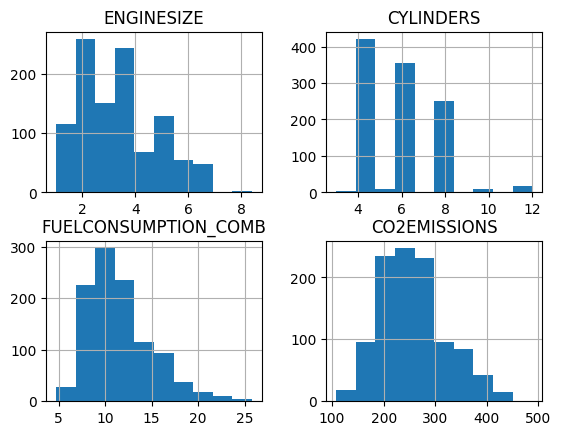

In [8]:
viz = cdf[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
viz.hist()
plt.show()

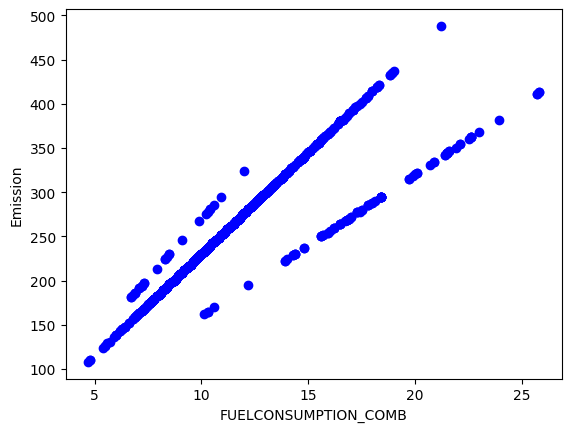

In [9]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

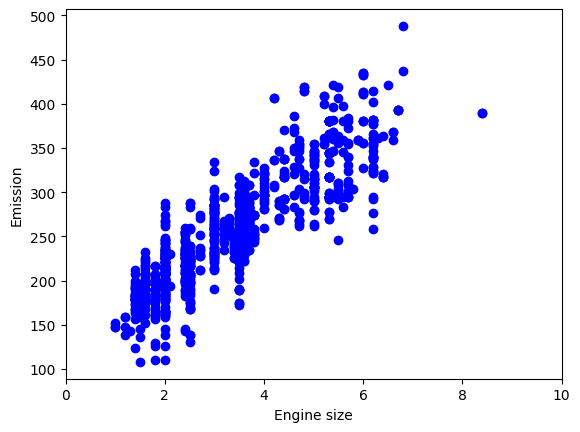

In [10]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.xlim(0,10)
plt.show()

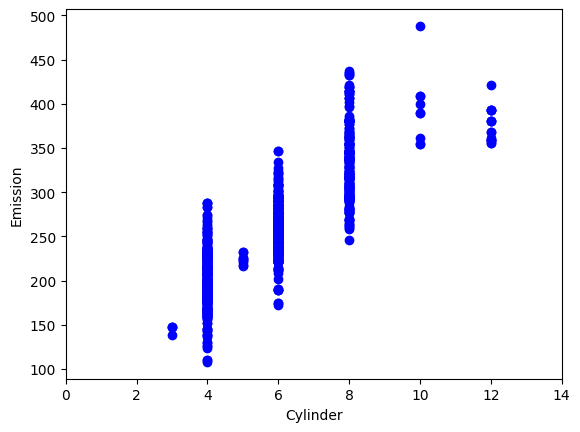

In [11]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Cylinder")
plt.ylabel("Emission")
plt.xlim(0,14)
plt.show()

In [13]:
# Extracting data to train regression model

X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

type(X_train), np.shape(X_train)

(numpy.ndarray, (853,))

In [14]:
#print(X_train)

from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model on the training data
# X_train is a 1-D array but sklearn models expect a 2D array as input for the training data, with shape (n_observations, n_features).
# So we need to reshape it. We can let it infer the number of observations using '-1'.
regressor.fit(X_train.reshape(-1, 1), y_train)

# Print the coefficients
print ('Coefficients: ', regressor.coef_[0]) # with simple linear regression there is only one coefficient, here we extract it from the 1 by 1 array.
print ('Intercept: ',regressor.intercept_)

[1.4 4.4 3.  3.  5.3 4.4 3.7 2.  4.  3.6 4.2 2.4 6.5 5.  5.7 3.7 6.2 3.5
 3.6 2.4 3.6 2.  2.  2.5 1.4 3.6 3.6 3.6 4.  2.  3.5 5.6 2.5 4.  3.5 1.6
 2.  3.5 5.3 3.7 2.  6.6 3.7 5.6 3.6 6.2 3.  1.4 4.4 4.3 5.  3.7 2.  3.6
 2.4 5.3 5.7 5.5 1.6 3.  3.5 4.  3.  1.6 2.4 3.  3.6 1.4 2.4 2.  3.  5.4
 2.4 4.8 2.  3.5 3.6 1.8 2.  4.6 5.3 2.4 5.8 5.  1.4 2.  2.7 1.8 2.5 4.
 6.  3.  3.  2.  1.2 2.4 3.  4.6 5.  2.  2.  1.6 2.  5.3 6.2 1.5 2.5 2.
 3.6 5.4 3.5 3.6 2.  4.4 3.  1.4 6.2 2.  6.  3.6 3.6 5.3 2.4 5.3 5.  5.3
 3.5 2.7 4.4 2.5 1.8 2.5 5.7 5.3 2.4 2.  6.2 1.6 2.  1.6 3.  2.5 5.3 3.5
 5.3 3.8 4.8 3.7 6.  2.5 2.4 1.6 3.8 6.2 2.5 1.6 2.  2.5 1.8 3.5 6.6 3.7
 1.5 2.4 2.  3.6 4.8 3.6 3.  1.5 2.7 1.6 2.4 5.  3.7 1.2 2.5 2.4 2.4 3.5
 2.  1.6 2.1 3.6 6.  2.  1.6 5.3 3.5 2.  2.4 3.6 3.5 1.5 2.  2.4 3.  3.
 3.  1.6 3.6 2.  3.5 2.5 3.7 3.8 3.7 2.  2.  5.  2.4 1.6 3.5 3.6 6.4 2.
 3.6 3.6 4.4 2.4 4.  2.  2.7 3.  1.8 6.2 2.  3.6 1.8 1.8 6.  3.6 4.4 6.4
 1.6 3.6 3.6 1.6 3.8 2.5 2.  1.6 4.8 2.  3.  3.3 6.2 3.

Text(0, 0.5, 'Emission')

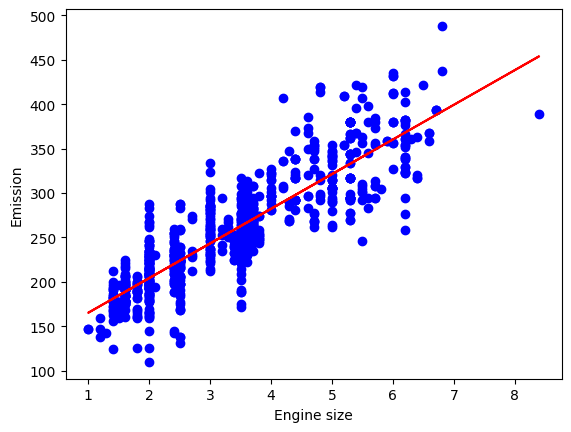

In [15]:
plt.scatter(X_train, y_train,  color='blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the predict method to make test predictions
y_pred = regressor.predict(X_test.reshape(-1,1))

# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Mean absolute error: 24.10
Mean squared error: 985.94
Root mean squared error: 31.40
R2-score: 0.76


In [ ]:
# Practice exercises

Text(0, 0.5, 'Emission')

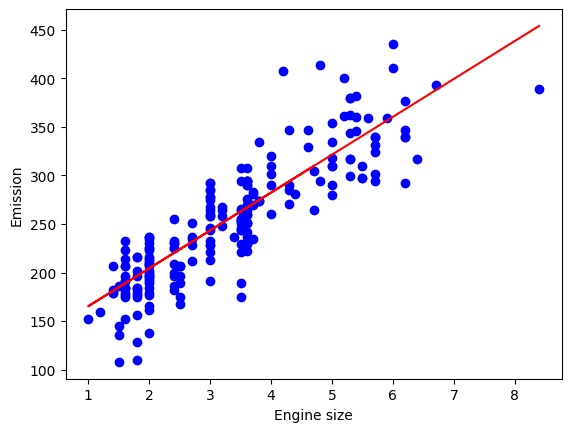

In [19]:
# 1. Plot the regression model result over the test data instead of the training data. Visually evaluate whether the result is good.
plt.scatter(X_test, y_test,  color='blue')
plt.plot(X_test, regressor.coef_ * X_test + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

Coefficients:  16.18090078119919
Intercept:  69.10302617988452


Text(0, 0.5, 'Emission')

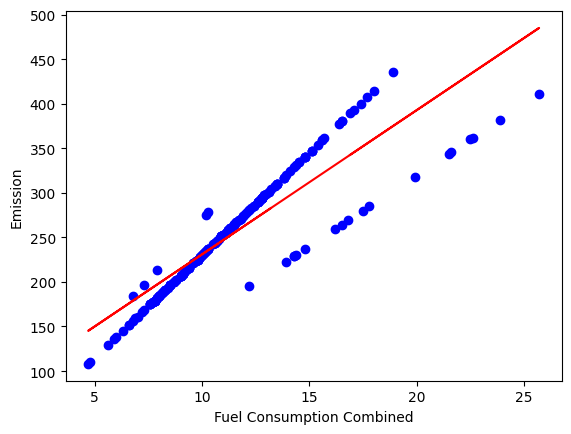

In [20]:
X = cdf.FUELCONSUMPTION_COMB.to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# create a model object
regressor = linear_model.LinearRegression()

# train the model on the training data
# X_train is a 1-D array but sklearn models expect a 2D array as input for the training data, with shape (n_observations, n_features).
# So we need to reshape it. We can let it infer the number of observations using '-1'.
regressor.fit(X_train.reshape(-1, 1), y_train)

# Print the coefficients
print ('Coefficients: ', regressor.coef_[0]) # with simple linear regression there is only one coefficient, here we extract it from the 1 by 1 array.
print ('Intercept: ',regressor.intercept_)

plt.scatter(X_test, y_test,  color='blue')
plt.plot(X_test, regressor.coef_ * X_test + regressor.intercept_, '-r')
plt.xlabel("Fuel Consumption Combined")
plt.ylabel("Emission")

In [21]:
# Use the predict method to make test predictions
y_pred = regressor.predict(X_test.reshape(-1,1))

# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Mean absolute error: 20.44
Mean squared error: 797.43
Root mean squared error: 28.24
R2-score: 0.81
